In [160]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from fontTools.subset import may_have_non_1to1


In [161]:
# 生成初始数据

random.seed(42)
np.random.seed(42)

machine_num = 10
job_num = 10
op_num_max = 5
op_num_min = 1
op_machine_max = 5
op_machine_min = 1
process_time_max = 10
process_time_min = 1

J = [] # [[[0,1],[2,3,4,5],[5]],[[5,6],[0,7,3]],...... ]
P = [] # [[[4,2],[5,2,7,2],[8]],[[3,4],[2,7,8]],...... ]
for job_id in range(job_num):
    op_num_temp = random.randint(op_num_min, op_num_max)
    job_machine = []
    job_time = []

    for i in range(op_num_temp):
        machine_num_temp = random.randint(op_machine_min, op_machine_max)
        available_machine = random.sample(range(machine_num), machine_num_temp)
        process_time = [random.randint(process_time_min, process_time_max) for _ in range(len(available_machine))]

        job_machine.append(available_machine)
        job_time.append(process_time)

    J.append(job_machine)
    P.append(job_time)

print(f'J = {J}')
print(f'P = {P}')


J = [[[4]], [[1, 8], [0, 9, 1, 7]], [[8, 6], [4, 0, 2, 5, 3], [1], [5], [4, 0, 7, 9, 8]], [[3, 1, 0, 5, 8], [7, 5, 2], [1, 2, 3]], [[3, 5, 0, 1, 7], [5, 3, 7, 8, 9], [8, 4, 6, 9, 3]], [[1]], [[9, 1, 6, 3], [0, 1, 4, 6, 5]], [[4], [8, 1], [3, 2, 5, 6, 1], [0, 1, 5, 6]], [[1], [8], [7, 8], [9, 6, 3, 4, 5], [7, 1, 3, 8, 0]], [[0, 1], [0], [8], [7, 3, 2], [7, 6]]]
P = [[[4]], [[2, 10], [4, 9, 10, 1]], [[4, 8], [6, 5, 3, 4, 6], [7], [6], [7, 2, 9, 5, 10]], [[5, 2, 4, 2, 7], [6, 6, 4], [3, 8, 7]], [[6, 7, 5, 2, 4], [8, 3, 5, 3, 4], [6, 4, 3, 9, 8]], [[3]], [[10, 8, 9, 5], [6, 2, 5, 7, 3]], [[9], [5, 9], [9, 9, 1, 10, 6], [5, 4, 1, 4]], [[8], [3], [3, 5], [4, 5, 7, 6, 8], [6, 1, 10, 9, 4]], [[1, 4], [6], [4], [10, 10, 8], [4, 2]]]


In [162]:
class FJSP_GA:
    def __init__(self, J, P, machine_num, pop_size, gen, crossover_rate, mutation_rate):

        self.J = J
        self.P = P
        self.job_num = len(J)
        self.machine_num = machine_num

        self.op_per_job = [len(job) for job in J]
        self.total_op_num = sum(self.op_per_job)

        self.pop_size = pop_size
        self.gen = gen
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate

        self.best_Cmax = float('inf')
        self.best_Ind = None
        self.convergence_history = []

    def GS(self): # 输出 MS = 每个工件的工序选择的机器，采用加工时间最短的策略
        MS = []
        machine_list = np.zeros(self.machine_num) # 累计机器加工时间

        for i in range(self.job_num): # 遍历所有工件
            for j in range(self.op_per_job[i]): # 遍历工件内所有工序
                available_machine = J[i][j] # J = [[0, 4], [0]], [[4, 0], [3, 1, 4, 2, 0]]
                process_time = P[i][j]
                min_time = 99999
                best_machine_idx = 0

                for m_idx in range(len(available_machine)): # 遍历所选工序所有的可行机器
                    machine = available_machine[m_idx] # 几号机器
                    total_time = machine_list[machine] + process_time[m_idx]
                    if total_time < min_time:
                        min_time = total_time
                        best_machine_idx = m_idx # 机器在工序可选机器中的序号

                MS.append(best_machine_idx)
                machine_list[available_machine[best_machine_idx]] += process_time[best_machine_idx]

        return MS

    def LS(self): # 输出 MS = 每个工件的工序选择的机器，采用加工时间最短的策略
        MS = []

        for i in range(self.job_num): # 遍历所有工件
            machine_list = np.zeros(self.machine_num) # 累计机器加工时间
            for j in range(self.op_per_job[i]): # 遍历工件内所有工序
                available_machine = J[i][j] # J = [[0, 4], [0]], [[4, 0], [3, 1, 4, 2, 0]]
                process_time = P[i][j]
                min_time = 99999
                best_machine_idx = 0

                for m_idx in range(len(available_machine)): # 遍历所选工序所有的可行机器
                    machine = available_machine[m_idx] # 几号机器
                    local_time = machine_list[machine] + process_time[m_idx]
                    if local_time < min_time:
                        min_time = local_time
                        best_machine_idx = m_idx # 机器在工序可选机器中的序号

                MS.append(best_machine_idx)
                machine_list[available_machine[best_machine_idx]] += process_time[best_machine_idx]

        return MS

    def RS(self):
        MS = []
        machine_list = np.zeros(self.machine_num)
        for i in range(self.job_num):
            for j in range(self.op_per_job[i]):
                MS.append(random.randint(0, len(J[i][j])-1))
        return MS

    def create_pop(self):
        '''
        采用混合策略GS+LS+RS生成初始种群，GS生成解更接近最优解，LS只考虑工件最早完成，不考虑全局机器使用情况，
        RS随机生成机器组合，全局性更好
        :return: pop
        '''
        pop = []
        gs_ms = self.GS()
        ls_ms = self.LS()
        os_template = []

        for i in range(self.job_num):
            os_template.extend([i] * self.op_per_job[i])

        count = round(self.pop_size//4)

        for i in range(count):
            random_os = os_template.copy()
            random.shuffle(random_os)
            pop.append(gs_ms + random_os)

        for i in range(count):
            random_os = os_template.copy()
            random.shuffle(random_os)
            pop.append(ls_ms + random_os)

        for i in range(self.pop_size - 2*count):
            rs_ms = self.RS()
            random_os = os_template.copy()
            random.shuffle(random_os)
            pop.append(rs_ms + random_os)

        return pop

# if __name__ == "__main__":
#     J = [[[0, 1], [0]], [[1, 0], [1, 1, 0,1, 0]]]
#     P = [[[2, 5], [3]], [[4, 2], [1, 3, 5, 2, 4]]]
#     machine_num = 2
#
#     test = FJSP_GA(J=J, P=P, machine_num=machine_num,
#                    pop_size = 50, gen = 100,
#                    crossover_rate = 0.7, mutation_rate = 0.1)
#     p = test.create_pop()
#     print(len(p))

    def decode(self, individual):
        '''
        解码，将输入解码为输出
        :param individual: [1,3,0,2,3,0,1,1,1,0]
        :return: T =  [[开始时间][工件号][工序号][结束时间]] 每一个工序一个结构
                 C =  [[工件i完工时间]，......]
        '''

        job_num = len(self.J)
        total_op_num = self.total_op_num

        ms = individual[:total_op_num] # ms = [2, 1, 0, 0, 1, 2, ...] 机器编号，可选机器idx
        os = individual[total_op_num:] # os = [0, 1, 2, 0, 1, 1, ...] 工序加工顺序

        machine_list = []
        idx = 0

        for i in range(job_num):
            op_count = len(self.J[i]) # 当前工件的工序数
            machine_list.append(ms[idx:idx + op_count]) # machine_list = [[2，1],[0,0,1],[2,...]]
            idx += op_count

        T = [[[0]] for _ in range(self.machine_num)]
        max_op_num = max(len(i) for i in self.J)
        C = np.zeros((self.job_num, max_op_num))
        k = [0] * self.job_num # 为后续遍历工件的工序

        for j in os:
            op = k[j] # 工序加工顺序
            m_idx = machine_list[j][op] # 机器在可选列表中的idx, e.g.: 第0个工件的第一个工序加工机器idx是2
            machine = self.J[j][op][m_idx] # e.g.: 在J里，第0个工件的第一个工序加工机器是1号机器
            process_time = self.P[j][op][m_idx] # e.g.: 在P里，这个机器的加工时间是2

            last_op_end = C[j][op - 1] if op > 0 else 0 # 第j个工件的上一个工序
            machine_last_end = T[machine][-1][-1] # 当前工序加工机器的最后一个工序的结束时间

            if machine_last_end >= last_op_end: # 当前工序的所选机器的加工结束时间大于上一个工序完成时间
                start_time = machine_last_end
                insert_ops = len(T[machine])
            else:
                start_time = max(machine_last_end, last_op_end)
                insert_ops = len(T[machine])
                for i in range(1, len(T[machine])): # 遍历当前机器所有加工工序
                    gap_start = max(T[machine][i-1][-1], last_op_end) # 选取所有加工工序的结束时间和当前工序上一道工序结束时间的最大值
                    gap_end = T[machine][i][0]
                    if gap_end - gap_start >= process_time: # 如果当前空隙大于当前工序的加工时间
                        start_time = gap_start
                        insert_ops = i
                        break

            end_time = start_time + process_time
            C[j][op] = end_time

            T[machine].insert(insert_ops, [int(start_time), int(j), int(op), int(end_time)])

            k[j] += 1
        return T, C

    def cross_ms(self, ms1, ms2):
        '''
        :param ms1: [1,3,0,2,3] in 2 jobs
        :param ms2: [0,1,2,1,2] in 2 jobs
        :return: child1, child2
        '''
        swap_job = random.sample(range(self.job_num), random.randint(0,self.job_num-1)) #选择交换工件，交换对应工件的工序所选的机器索引

        child1 = ms1.copy()
        child2 = ms2.copy()

        ms_indices = []
        current = 0
        for count in self.op_per_job: # [2,3]
            ms_indices.append((current, current + count))
            current += count
        for j in swap_job:
            start, end = ms_indices[j] # ms_indices = [(0,2),(2,5)]
            child1[start:end] = ms2[start:end]
            child2[start:end] = ms1[start:end]

        return child1, child2

    def cross_os(self, os1, os2):
        '''
        :param os1: [0,1,1,2,1,0,2] in 2 jobs
        :param os2: [2,1,2,0,0,1,1] in 2 jobs
        随机选择一部分工件，保留其在父代中的位置，另一部分从另一个父代按顺序填充
        :return: child1, child2
        '''
        job_ids = list(set(os1))
        perserve_jobs = random.sample(job_ids, random.randint(1,len(job_ids)-1)) # 0

        child1 = [None] * len(os1) # [None][None][None][None][None][None][None]
        for i in range(len(os1)): # i=0,1,2,3,4,5,6
            if os1[i] in perserve_jobs:
                child1[i] = os1[i] # child1 = [0][None][None][None][None][0][None]
        temp = [item for item in os2 if item not in perserve_jobs] # temp = [1,1,2,1,2]
        idx = 0
        for i in range(len(os1)): # i=0,1,2,3,4
            if child1[i] is None:
                child1[i] = temp[idx] # child1 = [0][1][1][2][0][1][2]
                idx += 1

        child2= [None] * len(os1) # [None][None][None][None][None]
        for i in range(len(os1)): # i=0,1,2,3,4
            if os2[i] in perserve_jobs:
                child2[i] = os2[i] # child2 = [None][0][0][None][None]
        temp = [item for item in os1 if item not in perserve_jobs] # temp = [1,1,1]
        idx = 0
        for i in range(len(os1)): # i=0,1,2,3,4
            if child2[i] is None:
                child2[i] = temp[idx] # child2 = [1][0][0][1][1]
                idx += 1

        return child1, child2

    def crossover(self, Ind1, Ind2):
        ms1 = Ind1[:self.total_op_num].copy()
        ms2 = Ind2[:self.total_op_num].copy()
        os1 = Ind1[self.total_op_num:].copy()
        os2 = Ind2[self.total_op_num:].copy()

        ms1_new, ms2_new = self.cross_ms(ms1, ms2)
        os1_new, os2_new = self.cross_os(os1, os2)

        return ms1_new + os1_new, ms2_new + os2_new

    def mutation_ms(self, ms):
        '''
        随机选择i个工序，在其可选机器中随机选择一个不同于当前的机器
        '''
        ms_new = ms.copy() # ms = [1,2,0,1,1]
        total_ops = self.total_op_num

        mutation_num = random.randint(1, round(total_ops//10))
        mutation_pos = random.sample(range(total_ops), mutation_num)

        pos = [] # ((0,0),(0,1),(1,0),(1,1),(1,2))
        for i in range(self.job_num):
            for j in range(self.op_per_job[i]):
                pos.append((i, j))

        for p in mutation_pos: # (1,3)
            i, j = pos[p] # i=1,j=1
            machine_num_temp = len(self.J[i][j]) # machine_num_temp = 4
            if machine_num_temp > 1:
                current = ms_new[p] # current = 1
                while True:
                    new_idx = random.randint(0, machine_num_temp - 1) # new_idx = 2
                    if new_idx != current:
                        ms_new[p] = new_idx
                        break
        return ms_new

    def mutation_os(self, os):
        '''
        随机选择一段OS序列进行suffle()
        '''
        os_new = os.copy()
        total_ops = len(os_new)
        idx1, idx2 = sorted(random.sample(range(len(os_new)), 2))
        segment = os_new[idx1:idx2+1]
        random.shuffle(segment)
        os_new[idx1:idx2+1] = segment
        return os_new

    def mutation(self, Ind):
        ms = Ind[:self.total_op_num].copy()
        os = Ind[self.total_op_num:].copy()

        ms_new = ms.copy()
        os_new = os.copy()

        if random.random() < self.mutation_rate:
            ms_new = self.mutation_ms(ms)
        if random.random() < self.mutation_rate:
            os_new = self.mutation_os(os)

        return ms_new + os_new

    def calculate_fitness(self, pop):
        fitness = []
        for ind in pop:
            fitness.append(self.decode(ind)[1].max())
        return fitness # 每一代中所有个体的最大加工完成时间组成列表

    def tournament_selection(self, fitness, k=3):
        selected_indices = []
        for _ in range(self.pop_size):
            candidates = random.sample(range(self.pop_size), k)
            best_candidate = min(candidates, key=lambda x: fitness[x])
            selected_indices.append(best_candidate)
        return selected_indices # len(selected_indices) = len(pop_size)

    def evolve(self, pop):
        '''
        :param pop:  旧种群
        :return: 生成新种群
        '''
        fitness = self.calculate_fitness(pop)

        selected_indices = self.tournament_selection(fitness)
        new_pop = [pop[i] for i in selected_indices]

        for i in range (0, self.pop_size, 2):
            if random.random() < self.crossover_rate and i+1 < self.pop_size:
                new_pop[i], new_pop[i+1] = self.crossover(new_pop[i], new_pop[i+1])

        for i in range(self.pop_size):
            if random.random() < self.mutation_rate:
                new_pop[i] = self.mutation(new_pop[i])

        return new_pop, fitness

    def run(self):
        '''
        遗传算法迭代
        '''
        pop = self.create_pop()
        for g in range(self.gen):
            pop, fitness = self.evolve(pop)

            current_best_idx = fitness.index(min(fitness)) # 当前pop中最小fitness的个体索引
            current_best_Cmax = fitness[current_best_idx] # 当前pop中最少完工时间

            if current_best_Cmax < self.best_Cmax:
                self.best_Cmax = current_best_Cmax
                self.best_Ind = pop[current_best_idx]
            print(f'第{g+1:3d}代 | 找到最新最优哦解：Cmax={self.best_Cmax}')

            self.convergence_history.append(self.best_Cmax)

        print('=' * 80)
        print(f'算法结束，算法最优解是{self.best_Cmax}')

        return self.best_Cmax, self.best_Ind

    def draw_gantt(self,):
        plt.rcParams['font.sans-serif'] = ['Heiti TC']
        plt.rcParams['axes.unicode_minus'] = False

        T, C = self.decode(self.best_Ind)

        fig, ax = plt.subplots(figsize=(16, 10))
        color_map = {}
        colors = plt.cm.cividis(np.linspace(0, 1, self.job_num))
        for j in range(self.job_num):
            color_map[j] = colors[j]

        for machine_idx, machine_tasks in enumerate(T):
            for task in machine_tasks[1:]:
                start, job, op, end = task
                color = color_map[job]

                ax.barh(y=machine_idx, width=end-start, left=start, height=0.6, color=color,
                        edgecolor='white', linewidth=0.5, zorder=1)
                lable = f'{job+1}-{op+1}'
                ax.text(x=(start+end)/2, y=machine_idx, s=lable, ha='center', va='center',
                        color = 'black',fontsize=20, fontweight='bold')

        plt.xlabel('加工时间',fontsize = 12)
        ax.set_yticks(range(self.machine_num))
        ax.set_yticklabels([f'机器{i+1}' for i in range(self.machine_num)], fontsize=11)
        ax.set_title(f'FJSP最优调度甘特图 (Cmax={self.best_Cmax})', fontsize=14, pad=20)

        legend_handles = []
        for j in range(self.job_num):
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, color=color_map[j], label=f'工件{j+1}'))
        ax.legend(handles=legend_handles, title='工件', loc='upper right',
                 bbox_to_anchor=(1.2, 1), fontsize=9, ncol=2)

        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()

    def plot_convergence(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.convergence_history, linewidth=2, color='#1f77b4')
        plt.xlabel('迭代次数', fontsize=12)
        plt.ylabel('最优完工时间(Cmax)', fontsize=12)
        plt.title('遗传算法收敛曲线', fontsize=14)
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()



第  1代 | 找到最新最优哦解：Cmax=29.0
第  2代 | 找到最新最优哦解：Cmax=29.0
第  3代 | 找到最新最优哦解：Cmax=29.0
第  4代 | 找到最新最优哦解：Cmax=29.0
第  5代 | 找到最新最优哦解：Cmax=29.0
第  6代 | 找到最新最优哦解：Cmax=28.0
第  7代 | 找到最新最优哦解：Cmax=28.0
第  8代 | 找到最新最优哦解：Cmax=28.0
第  9代 | 找到最新最优哦解：Cmax=28.0
第 10代 | 找到最新最优哦解：Cmax=28.0
第 11代 | 找到最新最优哦解：Cmax=28.0
第 12代 | 找到最新最优哦解：Cmax=28.0
第 13代 | 找到最新最优哦解：Cmax=28.0
第 14代 | 找到最新最优哦解：Cmax=28.0
第 15代 | 找到最新最优哦解：Cmax=28.0
第 16代 | 找到最新最优哦解：Cmax=28.0
第 17代 | 找到最新最优哦解：Cmax=28.0
第 18代 | 找到最新最优哦解：Cmax=28.0
第 19代 | 找到最新最优哦解：Cmax=28.0
第 20代 | 找到最新最优哦解：Cmax=28.0
第 21代 | 找到最新最优哦解：Cmax=28.0
第 22代 | 找到最新最优哦解：Cmax=28.0
第 23代 | 找到最新最优哦解：Cmax=28.0
第 24代 | 找到最新最优哦解：Cmax=28.0
第 25代 | 找到最新最优哦解：Cmax=28.0
第 26代 | 找到最新最优哦解：Cmax=28.0
第 27代 | 找到最新最优哦解：Cmax=28.0
第 28代 | 找到最新最优哦解：Cmax=28.0
第 29代 | 找到最新最优哦解：Cmax=28.0
第 30代 | 找到最新最优哦解：Cmax=28.0
第 31代 | 找到最新最优哦解：Cmax=28.0
第 32代 | 找到最新最优哦解：Cmax=28.0
第 33代 | 找到最新最优哦解：Cmax=28.0
第 34代 | 找到最新最优哦解：Cmax=28.0
第 35代 | 找到最新最优哦解：Cmax=28.0
第 36代 | 找到最新最优哦解：Cmax=28.0
第 37代 | 找到最新最优哦解：Cmax=28.0
第

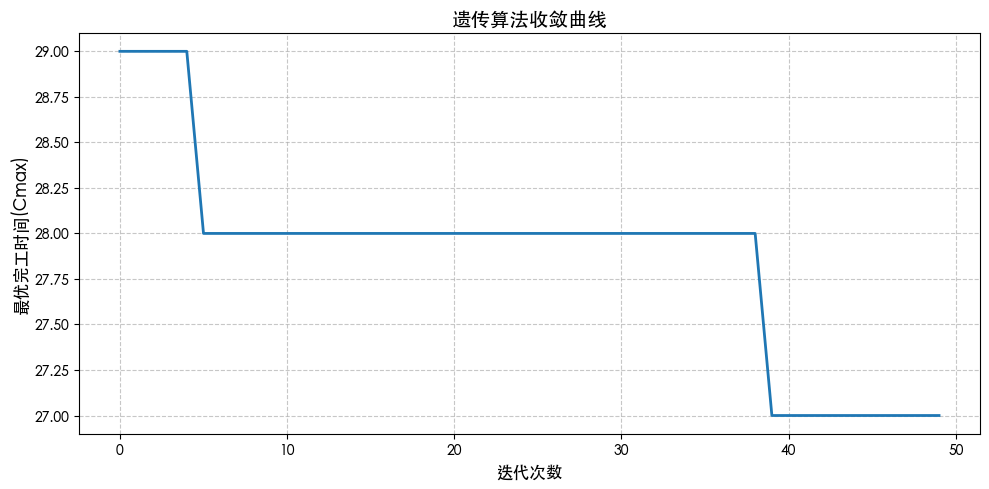

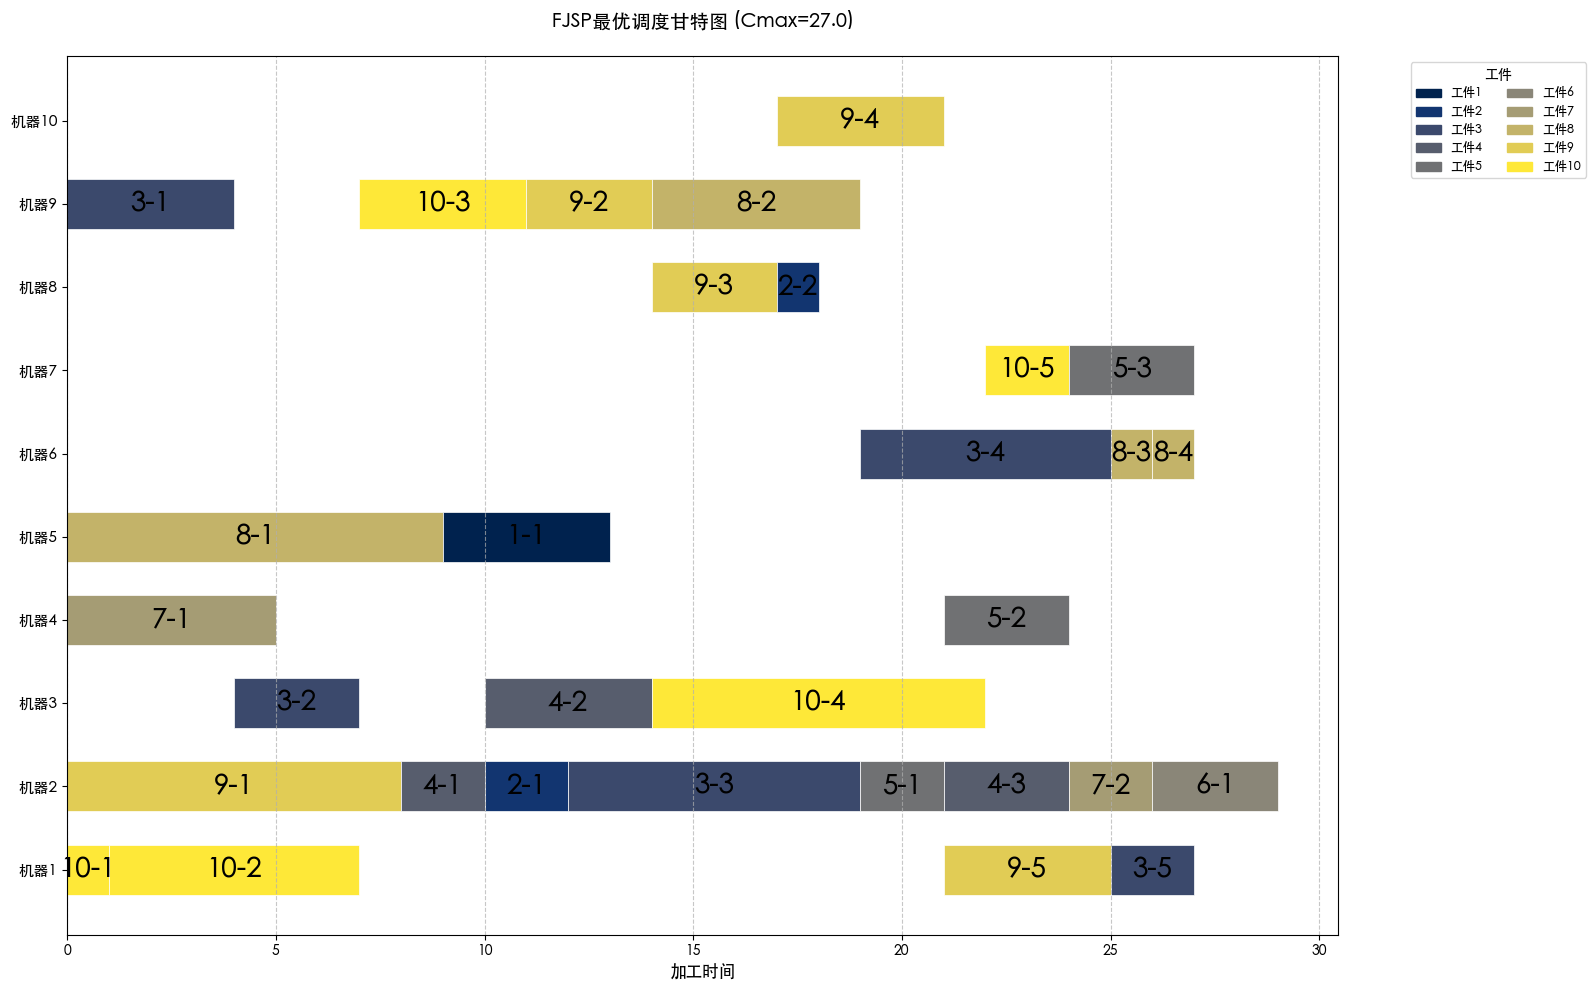

In [163]:
if __name__ == "__main__":
    # 初始化求解器
    solver = FJSP_GA(
        J=J,
        P=P,
        machine_num=machine_num,
        pop_size=60,
        gen=50,
        crossover_rate=0.8,
        mutation_rate=0.1
    )

    # 运行算法
    best_Cmax, best_ind = solver.run()

    # 绘制结果
    solver.plot_convergence()
    solver.draw_gantt()